<a href="https://colab.research.google.com/github/marinaesca12/Simulaci-n-GPs-Procesos-Gaussianos-/blob/main/GPs_PRADO_(MarinaEsca%C3%B1uelaHueso).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda obtendremos 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Además, visualizaremos el resultado obtenido, así como su shape.

Shape:  (50, 3)
Muestras: 
[[ 0.94644446 -0.5809104   0.17031163]
 [-0.60231446  0.41936513 -0.26110691]
 [-0.5719611   1.05877008 -0.16157244]
 [-0.61147205 -0.63825271  0.29646625]
 [-0.03154208  0.61947117  0.60587261]
 [-1.11591416  2.09383633 -0.5820184 ]
 [ 0.04285507  2.40983618 -0.44299087]
 [-0.41121014 -0.39528597 -0.58601222]
 [ 1.3869082   0.94340002  1.32414477]
 [ 1.26012502 -0.78371764 -0.57095159]
 [-0.04765099 -0.52772951 -0.70229476]
 [-0.26665243  0.34903004  2.55799215]
 [ 0.78294632  0.44481524  1.13543577]
 [ 0.42735638 -0.19261395  0.11450708]
 [ 1.56803514 -0.20398895  0.7644915 ]
 [-2.00358432  0.01821324 -0.23876566]
 [-0.25964085  0.76619785 -0.48116701]
 [ 0.98141736  0.73168949  0.01595344]
 [ 1.2858554   0.37041257 -0.05548835]
 [ 1.55146471 -1.27461775  1.05705749]
 [-0.25052313  0.75738333 -0.61181178]
 [-0.30271527 -0.63210942  0.35908895]
 [ 0.54804679 -0.24852904  1.43594377]
 [-0.04676232  0.85249884 -0.50711531]
 [ 0.58271255  1.11243591  0.50520238

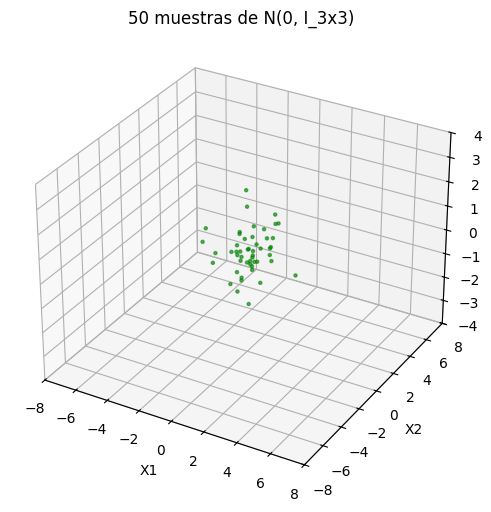

In [ ]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

## Ahora visualizamos el resultado obtenido :

# Creamos una hoja en 3D donde posteriormente dibujaremos el gráfico de dispersión :
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Creamos el gráfico de dispersión :
ax.scatter(samples[:,0], samples[:,1], samples[:,2], c='green', marker='.', alpha=0.6)

# Vamos a ajustar los límites de los ejes para que la proporción se vea bien :
ax.set_xlim([-8, 8])
ax.set_ylim([-8, 8])
ax.set_zlim([-4, 4])

# Añadimos etiquetas :
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('50 muestras de N(0, I_3x3)')

plt.show()

Ahora hacemos lo mismo pero para una normal con matriz de covarianzas $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$



<>:28: SyntaxWarning: invalid escape sequence '\S'
<>:28: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_47692/3982447775.py:28: SyntaxWarning: invalid escape sequence '\S'
  ax.set_title('50 muestras de N(0,$\Sigma$)')


Shape:  (50, 3)
Muestras: 
[[-1.44933125e+00  3.34751890e+00 -4.82485863e+00]
 [ 5.02972646e-01 -4.08857979e+00 -4.43241145e+00]
 [-2.04923270e-02  3.15357971e-01 -1.49011495e+01]
 [ 6.89033582e-01  6.01280983e+00  1.23435502e+00]
 [-2.13951702e-01 -4.55388710e+00  9.81062652e+00]
 [ 1.95029655e-02  5.44466657e+00 -5.07258856e+00]
 [-4.01047067e-01  5.71865942e+00 -7.10251056e+00]
 [-1.13803846e+00 -7.53535939e+00  4.85215519e+00]
 [-1.58233079e+00  2.12203535e+00  1.94905548e+01]
 [-6.09744832e-02 -2.16326954e+00 -1.78490299e+00]
 [ 2.71285806e-01  4.18251288e+00  2.20925717e+00]
 [ 2.65520506e+00 -4.93873410e+00  1.64693652e+01]
 [ 5.86813227e-02  1.02642493e+00  5.20439076e+00]
 [ 1.28589531e+00  1.57276004e+00  5.23875370e+00]
 [-1.55481342e+00 -5.49245705e+00  1.05264288e+01]
 [ 1.68243704e-01 -2.61213968e+00 -1.87068714e-01]
 [-6.03580903e-02 -1.16824394e+00 -7.77900470e+00]
 [ 1.74870475e-02 -8.64676035e-01 -3.41003784e-01]
 [ 1.20910543e-01  1.54671996e+00 -3.12088100e+00]
 [ 9

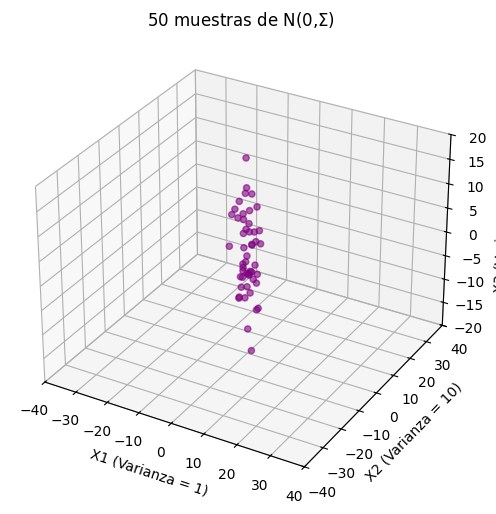

In [ ]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1, 10, 100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

## Ahora visualizamos el resultado obtenido :

# Creamos una hoja en 3D donde posteriormente dibujaremos el gráfico de dispersión :
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Creamos el gráfico de dispersión :
ax.scatter(samples[:,0], samples[:,1], samples[:,2], c='purple', marker='o', alpha=0.6)

# Vamos a ajustar los límites de los ejes para que la proporción se vea bien :
ax.set_xlim([-40, 40])
ax.set_ylim([-40, 40])
ax.set_zlim([-20, 20])

# Añadimos etiquetas :
ax.set_xlabel('X1 (Varianza = 1)')
ax.set_ylabel('X2 (Varianza = 10)')
ax.set_zlabel('X3 (Varianza =100)')
ax.set_title('50 muestras de N(0,$\Sigma$)')

plt.show()

¿Qué diferencias se pueden esperar ver en las muestras obtenidas??

Si viésemos ambos gráficos en la misma escala, las muestras de la primera normal parecerían un pequeño punto (casi invisible) comparado con la gran extensión que alcanzan las muestras de la segunda normal en el eje $X_3$. Por tanto, se han ajustado los límites de los ejes (set_xlim, set_ylim, set_zlim) a valores mucho más grandes en el segundo bloque de código.

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular un GP con kernel RBF. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función).

Definimos la función principal:

In [ ]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    """
    Simular un GP con kernel RBF.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    n = len(t)

    # Paso 1: Calculamos el vector de medias
    vector_medias = np.zeros_like(t)

    # Paso 2: Calculamos la matriz de covarianzas
    # t[:, None] tiene shape (n, 1) y t[None, :] tiene shape (1, n)
    matriz_de_diferencias = t[:, None] - t[None, :]

    # Aplicamos la fórmula del kernel RBF (sigma_sq * exp( - (distancia^2) / (2 * l^2)))
    matriz_covs = sigma_sq * np.exp(- (matriz_de_diferencias**2) / (2 * lengthscale**2))

    # Paso 3: Obtenemos las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)

    return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, generamos las trayectorias con la función recién definida, `simular_GP_RBF`, y las pintamos con `plt.plot`

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_47692/190299754.py:17: SyntaxWarning: invalid escape sequence '\s'
  axes[i].set_title(f'$\sigma = {s}$')


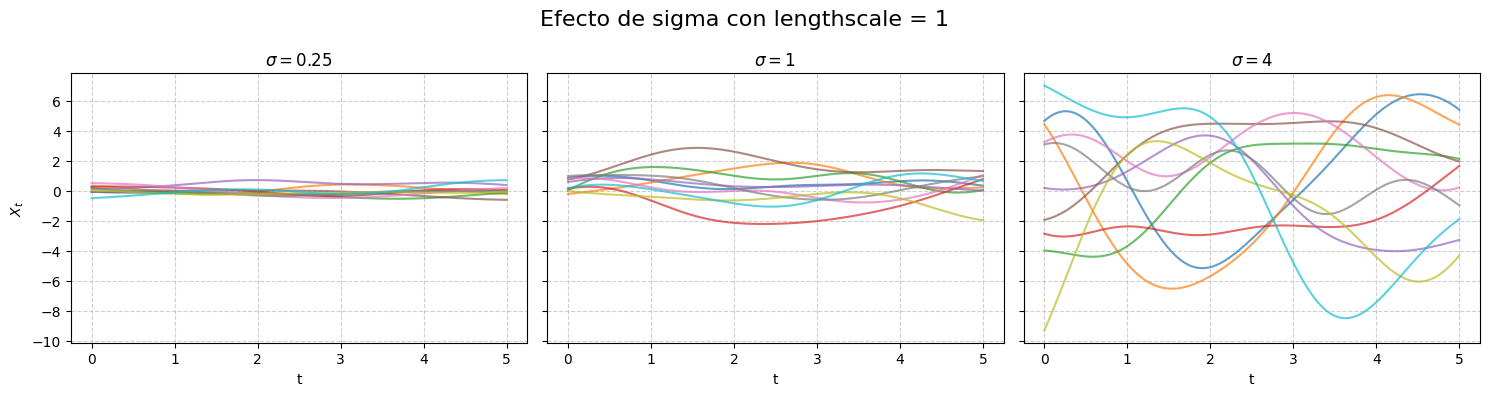

In [ ]:
## Para la diapositiva 59

# Definimos el grid (eje t) de 0 a 5 con 500 puntos
t = np.linspace(0, 5, 500)

sigmas = [0.25, 1, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Efecto de sigma con lengthscale = 1', fontsize=16)

for i, s in enumerate(sigmas):
    # Generamos 10 muestras para cada valor de sigma
    muestras = simular_GP_RBF(t, sigma_sq=s**2, lengthscale=1, num_samples=10)

    for j in range(10):
        axes[i].plot(t, muestras[j], lw=1.5, alpha=0.7)

    axes[i].set_title(f'$\sigma = {s}$')
    axes[i].set_xlabel('t')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    if i == 0: axes[i].set_ylabel('$X_t$')

plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_47692/3851672914.py:5: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle('Efecto de lengthscale con $\sigma = 1$', fontsize=16)


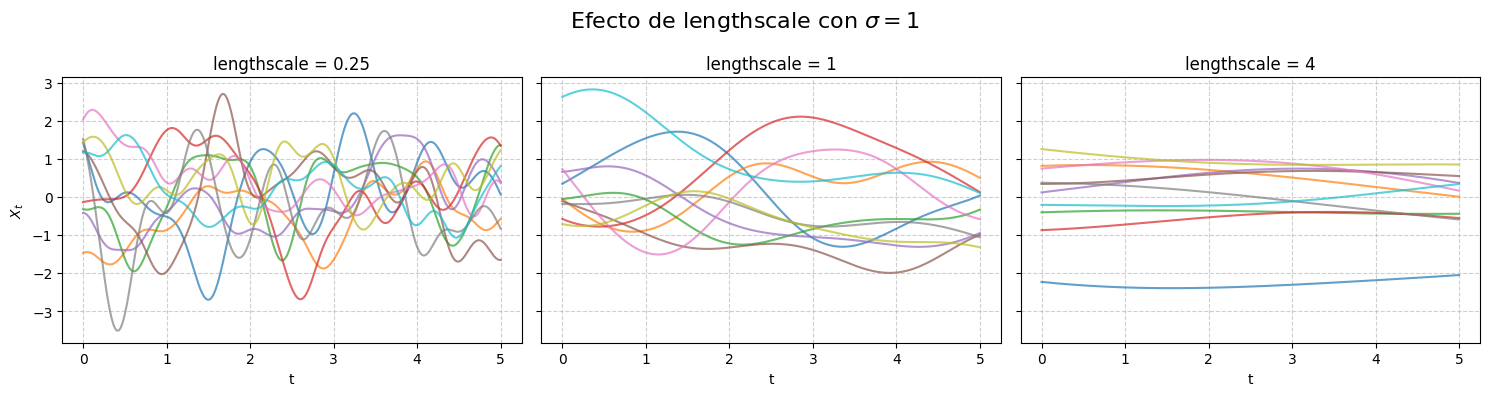

In [ ]:
## Para la diapositiva 62

ls = [0.25, 1, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Efecto de lengthscale con $\sigma = 1$', fontsize=16)

for i, l in enumerate(ls):
    # Generamos 10 muestras para cada valor de lengthscale
    muestras = simular_GP_RBF(t, sigma_sq=1, lengthscale=l, num_samples=10)

    for j in range(10):
        axes[i].plot(t, muestras[j], lw=1.5, alpha=0.7)

    axes[i].set_title(f'lengthscale = {l}')
    axes[i].set_xlabel('t')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    if i == 0: axes[i].set_ylabel('$X_t$')

plt.tight_layout()
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [ ]:
def kernel_periodico(t1, t2, sigma_sq, l, p):
    """
    Calcula la matriz de covarianza cruzada utilizando el kernel periódico.
    """
    # Convertimos las entradas a arrays 2D :
    t1 = np.asarray(t1).reshape(-1, 1)
    t2 = np.asarray(t2).reshape(-1, 1)

    # Calculamos la matriz de distancias absolutas d = |t1 - t2| :
    dist = np.abs(t1 - t2.T)

    # Aplicamos la fórmula matemática del kernel periódico :
    K = sigma_sq * np.exp(-2 * (np.sin(np.pi * dist / p)**2) / (l**2))
    return K

def simular_GP_periodic(t, num_muestras=5, sigma_sq=1.0, l=1.0, p=1.0):
    """
    Simula trayectorias de un GP con kernel periódico y medias cero.
    """
    # Definimos el vector de medias constantemente igual a 0 :
    mu = np.zeros(len(t))

    # Calculamos la matriz de covarianza evaluando el kernel en todos los pares de t :
    K = kernel_periodico(t, t, sigma_sq, l, p)

    # Generamos trayectorias con la distribución normal multivariante :
    muestras = np.random.multivariate_normal(mu, K, num_muestras)

    return muestras

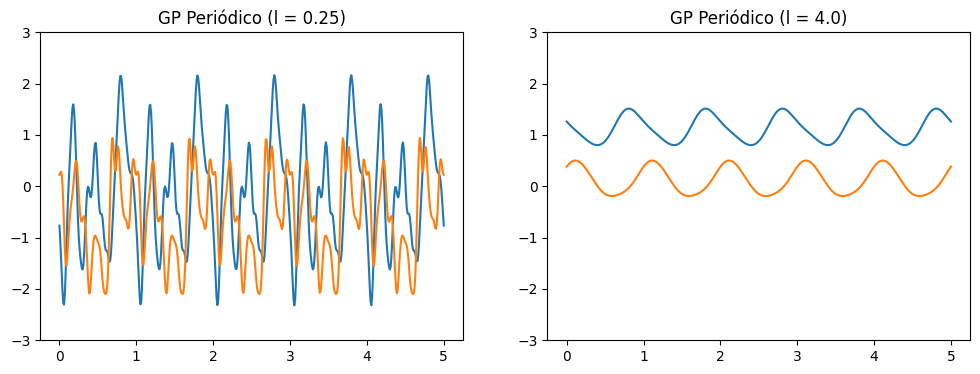

In [ ]:
# Imágenes de la diapositiva 72 :

t = np.linspace(0, 5, 500)
num_trayectorias = 2 # Dibujaremos 2 trayectorias por gráfico

muestras_72_izq = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=1.0, l=0.25, p=1.0)
muestras_72_der = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=1.0, l=4.0, p=1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, muestras_72_izq.T)
axes[0].set_title("GP Periódico (l = 0.25)")
axes[0].set_ylim(-3, 3)

axes[1].plot(t, muestras_72_der.T)
axes[1].set_title("GP Periódico (l = 4.0)")
axes[1].set_ylim(-3, 3)
plt.show()

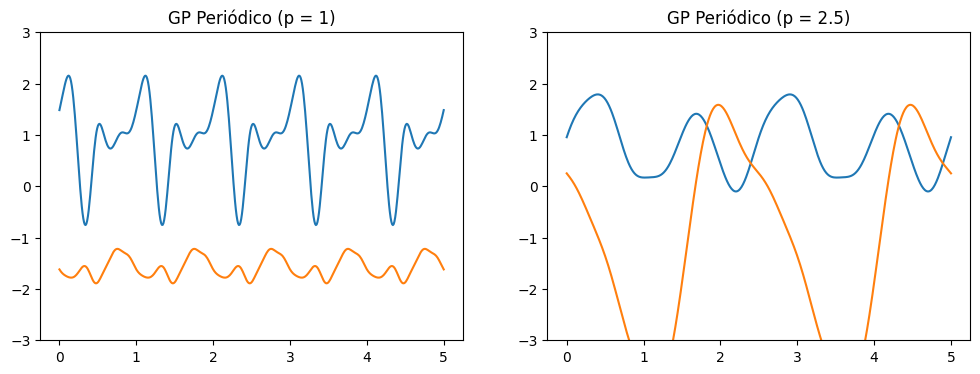

In [ ]:
# Imágenes de la diapositiva 74 :

muestras_74_izq = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=1.0, l=1.0, p=1.0)
muestras_74_der = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=1.0, l=1.0, p=2.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, muestras_74_izq.T)
axes[0].set_title("GP Periódico (p = 1)")
axes[0].set_ylim(-3, 3)

axes[1].plot(t, muestras_74_der.T)
axes[1].set_title("GP Periódico (p = 2.5)")
axes[1].set_ylim(-3, 3)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11918/3834164407.py:8: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title("GP Periódico ($\sigma$ = 1)")
/tmp/ipykernel_11918/3834164407.py:12: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title("GP Periódico ($\sigma$ = 4)")


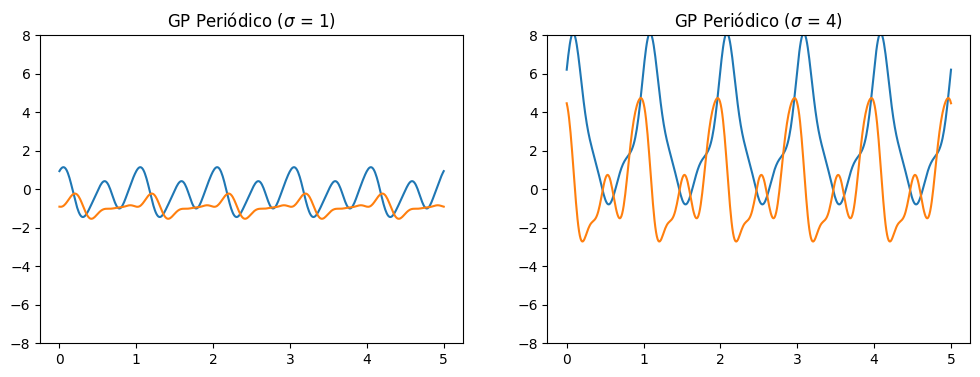

In [ ]:
# Imágenes de la diapositiva 76 :

muestras_76_izq = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=1.0, l=1.0, p=1.0)
muestras_76_der = simular_GP_periodic(t, num_muestras=num_trayectorias, sigma_sq=16.0, l=1.0, p=1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, muestras_76_izq.T)
axes[0].set_title("GP Periódico ($\sigma$ = 1)")
axes[0].set_ylim(-8, 8)

axes[1].plot(t, muestras_76_der.T)
axes[1].set_title("GP Periódico ($\sigma$ = 4)")
axes[1].set_ylim(-8, 8)
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usaremos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [ ]:
def kernel_DPKpoly(t1, t2, m):
    """
    Calculamos la matriz de covarianza cruzada utilizando el kernel DPK
    con funciones base polinómicas 1, t, t^2, ..., t^m.
    """
    t1 = np.asarray(t1).reshape(-1, 1)
    t2 = np.asarray(t2).reshape(-1, 1)

    # Definimos la matriz del kernel con ceros :
    K = np.zeros((len(t1), len(t2)))

    # Sumamos el producto de cada función base (f_k(t) = t^k) :
    for k in range(m + 1):
        K += (t1 ** k) @ (t2.T ** k)

    return K

def simular_GP_DPKpoly(t, m, num_muestras=5):
    """
    Simulamos trayectorias de un GP con kernel DPK polinómico (hasta grado m)
    y vector de medias cero.
    """
    # Definimos el vector de medias constantemente igual a 0 :
    mu = np.zeros(len(t))

    # Calculamos la matriz de covarianza :
    K = kernel_DPKpoly(t, t, m)

    # Generamos las trayectorias.
    muestras = np.random.multivariate_normal(mu, K + 1e-8 * np.eye(len(t)), num_muestras)

    return muestras

In [ ]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simulamos un GP con kernel DPK con funciones base 1, t, ..., t^m.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo de los monomios utilizados. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """

    n = len(t)

    # Paso 1: Calculamos el vector de medias.
    vector_medias = np.zeros(n)   # Shape: (n,)

    # Paso 2: Calculamos la matriz de covarianzas.
    # [OPCIÓN 1: USAR UN BUCLE FOR SOBRE M; ES ACEPTABLE PORQUE USAREMOS M BAJO]
    matriz_covs = np.zeros((n, n))

    for k in range(m + 1):
         tk = t**k
         matriz_covs += np.outer(tk, tk)

    # Paso 2: Calculamos la matriz de covarianzas.
    # [OPCIÓN 2: Usando el producto matricial F*F^T visto en la diapositiva 82]
    F = np.column_stack([t**k for k in range(m + 1)])
    matriz_covs = F @ F.T

    # Paso 2: Calculamos la matriz de covarianzas.
    # [OPCIÓN 3: Usando el broadcasting, sería lo "más análogo" a lo usado para RBF/periódico, pero requiere usar arrays 3D en este caso]
    powers = np.arange(m + 1)
    matriz_covs = np.sum((t[:, None, None]**powers) * (t[None, :, None]**powers), axis=2)

    # En cualquiera de las OPCIONES anteriores, la matriz de covarianzas resultante podría no ser semidefinida positiva (por problemas numéricos de redondeo).
    # Para resolverlo, es muy habitual y recomendable sumar un "jitter" o ruido definido positivo, es decir, sumar por ejemplo la identidad multplicada por un valor pequeño:
    matriz_covs = matriz_covs + 1e-9 * np.eye(n)

    # Paso 3: obtén las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)

    return samples

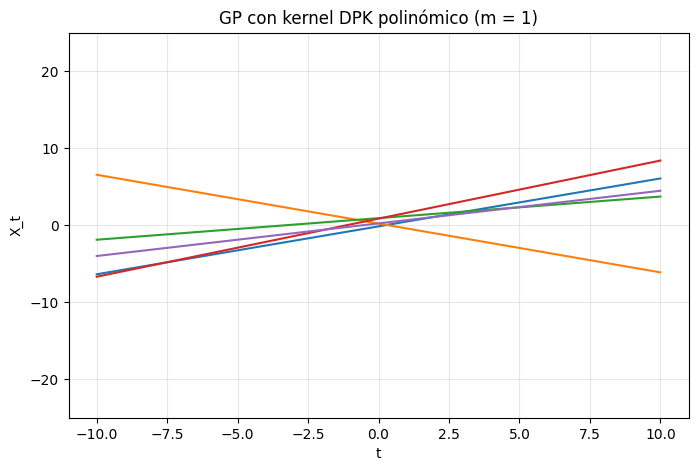

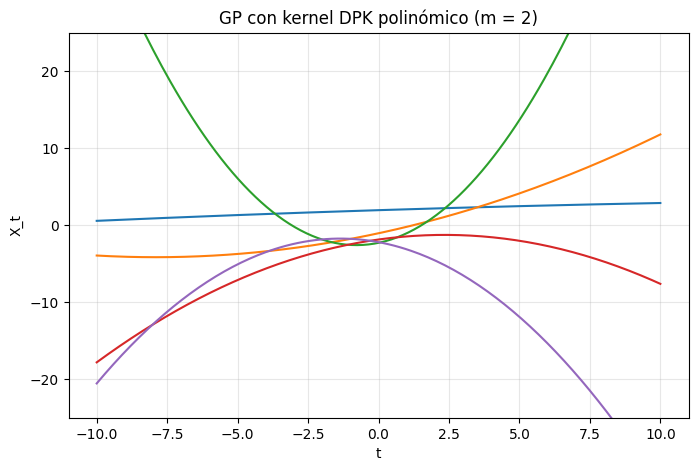

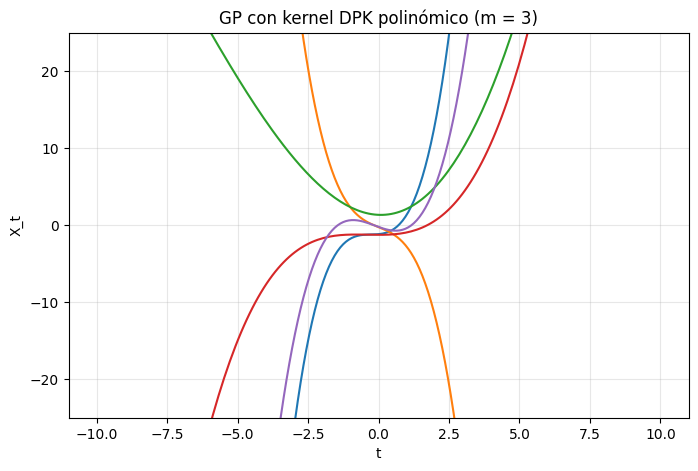

In [ ]:
# Completamos para la diapositiva 89 :

# Definimos el rango de t de -10 a 10 :
t_89 = np.linspace(-10, 10, 200)

# Simulamos con m=1, m=2 y m = 3 :

muestras_m1 = simular_GP_DPKpoly(t_89, m=1, num_samples=5)
muestras_m2 = simular_GP_DPKpoly(t_89, m=2, num_samples=5)
muestras_m3 = simular_GP_DPKpoly(t_89, m=3, num_samples=5)

# Graficamos :

# Para m=1 :
plt.figure(figsize=(8, 5))
plt.plot(t_89, muestras_m1.T)
plt.title("GP con kernel DPK polinómico (m = 1)")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(True, alpha=0.3)
plt.ylim(-25, 25)
plt.show()

# Para m=2 :
plt.figure(figsize=(8, 5))
plt.plot(t_89, muestras_m2.T)
plt.title("GP con kernel DPK polinómico (m = 2)")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(True, alpha=0.3)
plt.ylim(-25, 25)

# Para m=3 :
plt.figure(figsize=(8, 5))
plt.plot(t_89, muestras_m3.T)
plt.title("GP con kernel DPK polinómico (m = 3)")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(True, alpha=0.3)
plt.ylim(-25, 25)
plt.show()

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [2]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [3]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [4]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [5]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [6]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [7]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8909/2415945677.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"GP with identity mean function (RBF kernel: $\sigma^2$: {sigma}; l:{lengthscale})")


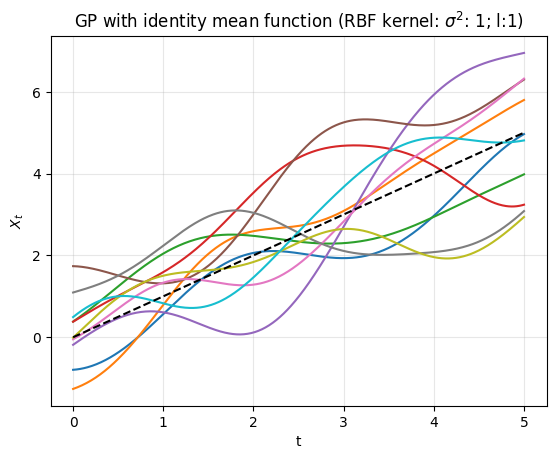

In [10]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: $\sigma^2$: {sigma}; l:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()
